# Export Variability Metrics

This notebook builds one DataFrame with variability fields and provides one plotting function to inspect g-band light curves and the binned points used for the variability calculation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from qvc.light_curve.fit_light_curves import make_lc
from qvc.light_curve.multiband_generate_lc import concat_light_curves, populate_sdss_fields
from qvc.light_curve.variability_metrics import (
    compute_binned_chi_squared,
    compute_variability_metrics_for_cleaned_lc,
    gap_aligned_bins,
    reconstruct_cleaned_by_band,
)

/home/dutra/.conda/envs/jaxcpu4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
OUTPUT_CSV = Path("data/lc_variability_metrics.csv")
FILTER_OBJECT_IDS = None  # e.g. ["1465126"]
SKIP = None
N = None  # Set to None for the full sample.
BANDS = ["g"]

In [3]:
objs = concat_light_curves(
    filter_object_ids=FILTER_OBJECT_IDS,
    progress_bar=True,
    skip=SKIP,
    N=N,
)
objs = populate_sdss_fields(objs, progress_bar=True)
print(f"Loaded {len(objs)} objects")

[DEBUG] Loading concat_light_curves with filter_object_ids=None, skip=None, N=None
Found 38825 matching objects in concat_light_curves_jax


Packaging quasars: 100%|██████████| 38825/38825 [00:04<00:00, 8647.14it/s]
2026-03-30 12:15:30 - No table::len::objectId found in metadata. Using longest string (7 characters).


Found 38825 objects in concat_light_curves_jax
Loaded 38825 objects


In [4]:
cleaned_lc_cache = {}
rows = []

for obj in tqdm(objs, desc="Computing variability metrics"):
    cleaned_lc = make_lc(
        obj,
        bands=list(BANDS),
        inject_fake=False,
        drop_band_lyman_alpha=False,
        verbose=False,
    )
    if cleaned_lc is None:
        continue

    object_id = str(obj["object_id"])
    cleaned_lc_cache[object_id] = cleaned_lc

    row = {
        "object_id": object_id,
        "RA": obj.get("RA", obj.get("ra", np.nan)),
        "DEC": obj.get("DEC", obj.get("dec", np.nan)),
        "sdss_name": obj.get("sdss_name", np.nan),
    }
    row.update(compute_variability_metrics_for_cleaned_lc(cleaned_lc))
    rows.append(row)

df_variability = pd.DataFrame(rows)
print(f"Built DataFrame with {len(df_variability)} rows")

Computing variability metrics:   0%|          | 0/38825 [00:00<?, ?it/s]2026-03-30 12:15:33 - Unable to initialize backend 'cuda': 
2026-03-30 12:15:33 - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-03-30 12:15:33 - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-03-30 12:15:33 - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Computing variability metrics: 100%|██████████| 38825/38825 [00:53<00:00, 720.39it/s] 


Built DataFrame with 38825 rows


In [5]:
df_variability.head()

,object_id,RA,DEC,sdss_name,variability_n_points_g,variability_n_valid_bins_g,variability_dof_g,variability_chi_sq_g,variability_chi_sq_red_g,variability_pvalue_g,variability_neg_log10_pvalue_g
0,1444819,0.001978,-0.451088,b'000000.47-002703.9',158,17,16.0,1028.691644,64.293228,8.030510e-209,208.095257
1,1444815,0.006464,-0.559066,b'000001.55-003332.6',61,13,12.0,222.196296,18.516358,8.314769e-41,40.080150
2,1444814,0.006855,0.583184,b'000001.64+003459.4',77,15,14.0,573.265739,40.947553,2.586453e-113,112.587295
3,1444813,0.008067,-0.240971,b'000001.93-001427.4',256,15,14.0,2777.216036,198.372574,0.000000e+00,NaN
4,1444808,0.013630,0.192449,b'000003.27+001132.8',31,7,6.0,185.599185,30.933198,2.193160e-37,36.658930


In [6]:
# OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
# df_variability.to_csv(OUTPUT_CSV, index=False)
# print(f"Wrote {len(df_variability)} rows to {OUTPUT_CSV}")

In [7]:
def plot_variability_row(row, band="g"):
    object_id = str(row["object_id"])
    cleaned_lc = cleaned_lc_cache[object_id]
    times_by_band, mags_by_band, errs_by_band = reconstruct_cleaned_by_band(cleaned_lc)

    times = np.asarray(times_by_band[band], dtype=float)
    mags = np.asarray(mags_by_band[band], dtype=float)
    errs = np.asarray(errs_by_band[band], dtype=float)

    bin_edges = gap_aligned_bins(times)
    binned = compute_binned_chi_squared(times, mags, errs, bin_edges)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    valid_bins = np.isfinite(binned.bin_means) & np.isfinite(binned.bin_errors) & (binned.bin_errors > 0)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(times, mags, yerr=errs, fmt="o", ms=4, alpha=0.7, color="tab:green", label=f"{band}-band")
    ax.errorbar(
        bin_centers[valid_bins],
        binned.bin_means[valid_bins],
        yerr=binned.bin_errors[valid_bins],
        fmt="s",
        ms=7,
        color="black",
        label="Binned means",
    )
    ax.invert_yaxis()
    ax.set_xlabel("MJD")
    ax.set_ylabel("Mean-centered magnitude")
    ax.set_title(f"object_id={object_id} | sdss_name={row.get('sdss_name', '')}")
    ax.legend(loc="best")
    ax.grid(alpha=0.2)

    text = "\n".join([
        f"variability_n_points_g = {row.get('variability_n_points_g', np.nan)}",
        f"variability_n_valid_bins_g = {row.get('variability_n_valid_bins_g', np.nan)}",
        f"variability_dof_g = {row.get('variability_dof_g', np.nan)}",
        f"variability_chi_sq_g = {row.get('variability_chi_sq_g', np.nan):.4g}" if np.isfinite(row.get('variability_chi_sq_g', np.nan)) else "variability_chi_sq_g = nan",
        f"variability_chi_sq_red_g = {row.get('variability_chi_sq_red_g', np.nan):.4g}" if np.isfinite(row.get('variability_chi_sq_red_g', np.nan)) else "variability_chi_sq_red_g = nan",
        f"variability_pvalue_g = {row.get('variability_pvalue_g', np.nan):.4g}" if np.isfinite(row.get('variability_pvalue_g', np.nan)) else "variability_pvalue_g = nan",
        f"variability_neg_log10_pvalue_g = {row.get('variability_neg_log10_pvalue_g', np.nan):.4g}" if np.isfinite(row.get('variability_neg_log10_pvalue_g', np.nan)) else "variability_neg_log10_pvalue_g = nan",
    ])
    ax.text(
        1.02,
        0.98,
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        family="monospace",
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
    )
    plt.tight_layout()
    return fig, ax

Length of dataframe after cut: 31391


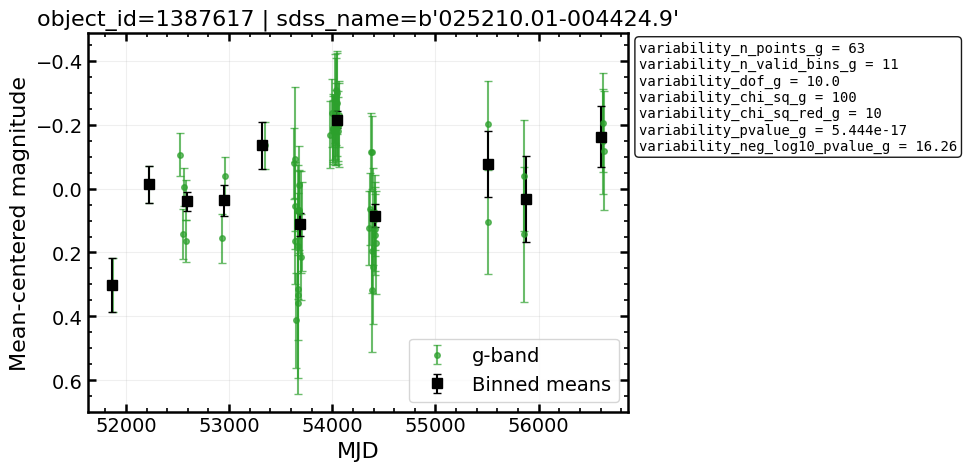

In [12]:
# Example:
d = df_variability[df_variability["variability_chi_sq_red_g"] > 10]
row = d.sort_values("variability_chi_sq_red_g", ascending=True).iloc[0]
plot_variability_row(row)
print(f"Length of dataframe after cut: {len(d)}")